<a href="https://colab.research.google.com/github/Musaibsayyad/MLT-Practicals/blob/main/Exp_3_Implementation_of_logistic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic regression**

# **Step 1 : Data collection**

Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [ ]:
titanic_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic_data (1).csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(str(len(titanic_data.index)))# total no of passengers in orignal data

891


# **Step 2 : Analyzing the data**
!!! knowing the data
!!! plotting graphs
!!! EDA

<Axes: xlabel='Survived', ylabel='count'>

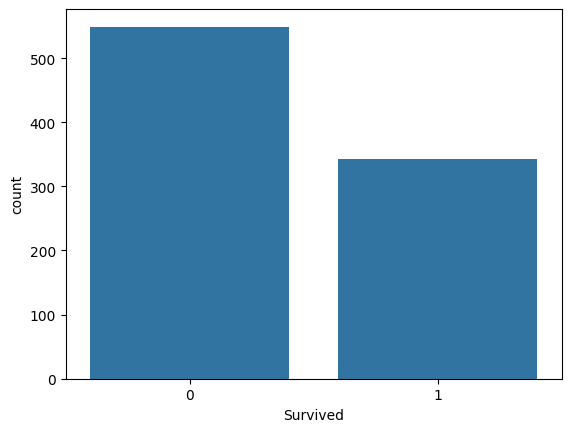

In [ ]:
#knowing how many people survived and died
sns.countplot(x='Survived',data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

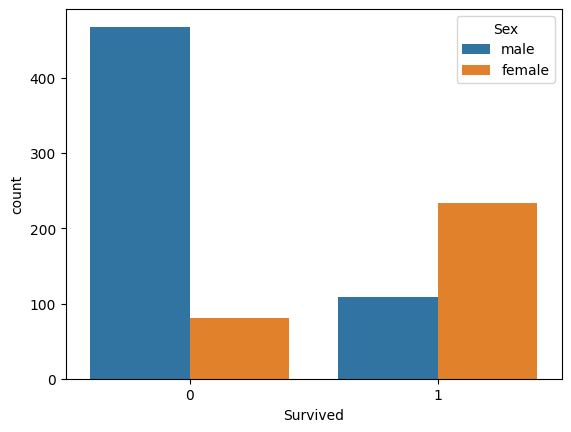

In [ ]:
#knowing howmany male survided and how many females survived
sns.countplot(x='Survived',hue='Sex',data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

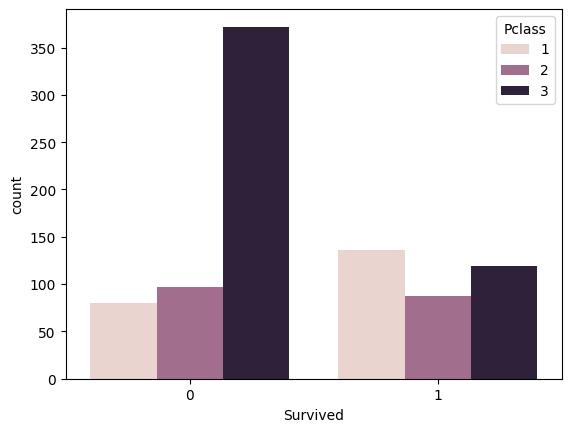

In [ ]:
#Knowing which class people survived the most
sns.countplot(x='Survived',hue='Pclass',data=titanic_data)

<Axes: ylabel='Frequency'>

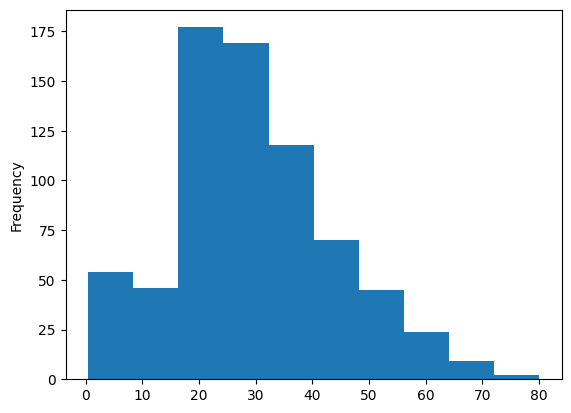

In [ ]:
#Age distribution
titanic_data['Age'].plot.hist()

<Axes: ylabel='Frequency'>

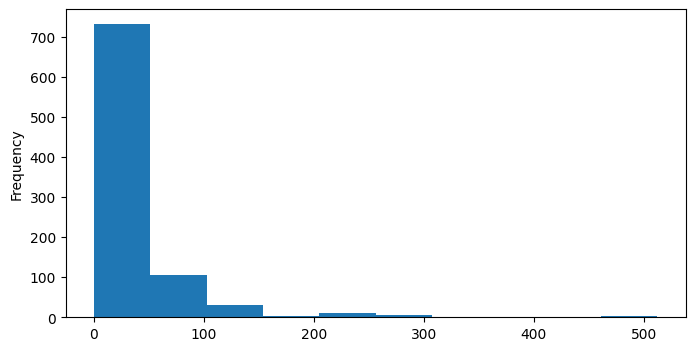

In [ ]:
#fare- the amount of money a passenger paid for their tickit
titanic_data['Fare'].plot.hist(figsize=(8,4))

Exploratory data Analysis

In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Step 3 : Data Preprocessing**
!!! Data cleaning (Removing impurities)
!!! Imputation

In [ ]:
titanic_data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#imputation
titanic_data.drop('Cabin',axis=1,inplace=True)

In [ ]:
titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [ ]:
titanic_data.dropna(inplace=True)

In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Converting data from one form to another

In [ ]:
titanic_data.head(5)
# we will first convert categorical variables into dummy variabls and then use them as logistic reg only takes 2 inputs

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Encoding

Using logistic regression we will predict how many people survived and how many died in titanic ship.
here 1 survived and 0 died.

In [ ]:
pd.get_dummies(titanic_data['Sex']).astype(int)


,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


In [ ]:
S = pd.get_dummies(titanic_data['Sex'],drop_first=True).astype(int)
S.head(4)

,male
0,1
1,0
2,0
3,0


In [ ]:
#conversion of Embarked column from one form to another
#Q= Quinstown, S=southam , C= chambor
E = pd.get_dummies(titanic_data['Embarked'],drop_first=True).astype(int).astype(int)
E.head(4)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1


In [ ]:
#conversion of Pclass column from one form to another
P = pd.get_dummies(titanic_data['Pclass'],drop_first=True).astype(int).astype(int)
P.head(4)

,2,3
0,0,1
1,0,0
2,0,1
3,0,0


In [ ]:
#concatinate all the new rows in the dataset
titanic_data = pd.concat([titanic_data,S,E,P],axis=1)

In [ ]:
titanic_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S,2,3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,1,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0,1,0,1


In [ ]:
titanic_data.drop(['Sex','Embarked','PassengerId','Name','Ticket','Pclass'],axis=1,inplace=True)

In [ ]:
#our final dataset
titanic_data.head(5)

,Survived,Age,SibSp,Parch,Fare,Cabin,male,Q,S,2,3
0,0,22.0,1,0,7.2500,NaN,1,0,1,0,1
1,1,38.0,1,0,71.2833,C85,0,0,0,0,0
2,1,26.0,0,0,7.9250,NaN,0,0,1,0,1
3,1,35.0,1,0,53.1000,C123,0,0,1,0,0
4,0,35.0,0,0,8.0500,NaN,1,0,1,0,1


# **Step 4 : Split Training and testing the data**


**Train Data**

In [ ]:
X = titanic_data.drop('Survived',axis=1)# accept survived all the other columns are indep var
y = titanic_data['Survived']

splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

Implementing logistic regression

!!! Creating our Model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
# Drop non-numeric 'Cabin' column and handle missing values before training
if 'Cabin' in X_train.columns:
    X_train = X_train.drop('Cabin', axis=1)
if 'Cabin' in X_test.columns:
    X_test = X_test.drop('Cabin', axis=1)

# Impute missing Age values if they still exist
if X_train['Age'].isnull().any():
    X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
if X_test['Age'].isnull().any():
    X_test['Age'] = X_test['Age'].fillna(X_train['Age'].median())

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#X_test.columns = X_test.columns.astype(str)
predictions = model.predict(X_test)

# **Step 5 : Predictions**

In [ ]:
print("Predictions:")
print(predictions)

Predictions:
[1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 0 0 1 0 0 0
 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 1
 0 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0
 1 1 0 1 1 0 0 0 0]


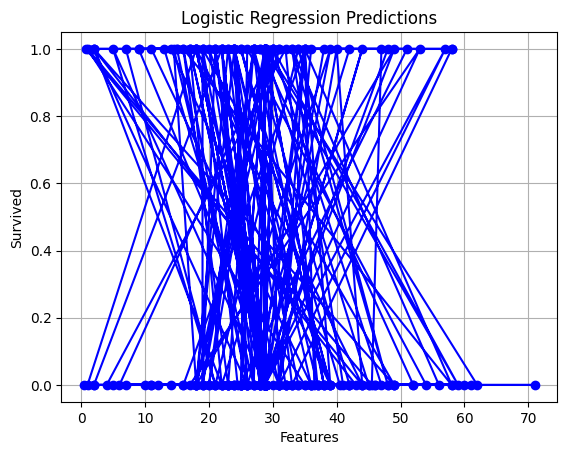

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already have your trained model and test data
# model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Plot predicted classes vs the first feature of X_test
plt.plot(X_test.iloc[:, 0], predictions, marker='o', linestyle='-', color='blue')
plt.xlabel('Features')
plt.ylabel('Survived')
plt.title('Logistic Regression Predictions')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
print(confusion_matrix(y_test,predictions))

[[131  22]
 [ 39  76]]


In [ ]:
# Step 6 : Checking the Accuracy
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,predictions)

0.7723880597014925